# Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Read the dataset
df = pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
# Drop unnecessary columns 
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [ ]:
# Check for null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

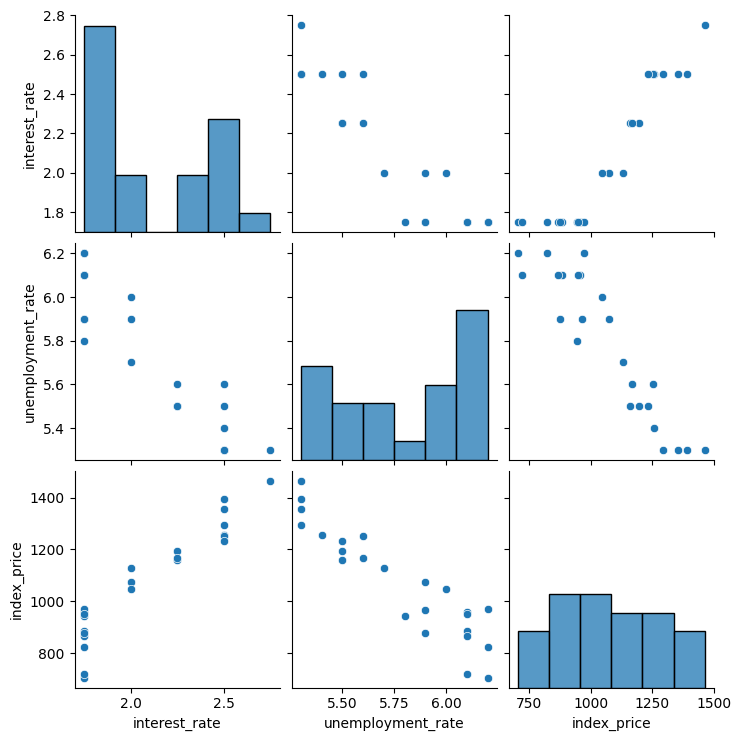

In [6]:
# Data visualization
sns.pairplot(df)

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

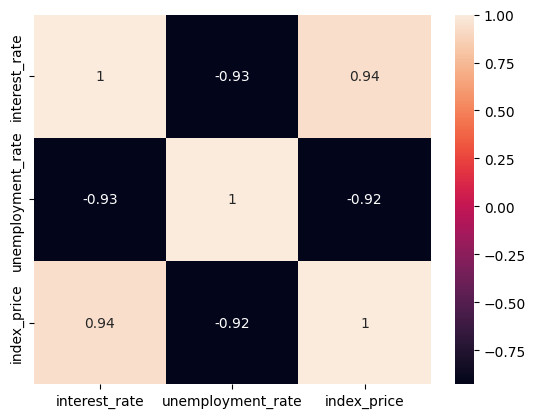

In [8]:
sns.heatmap(df.corr(),annot=True)

Text(0.5, 1.0, 'Relationship between Interest and Unemployment rate')

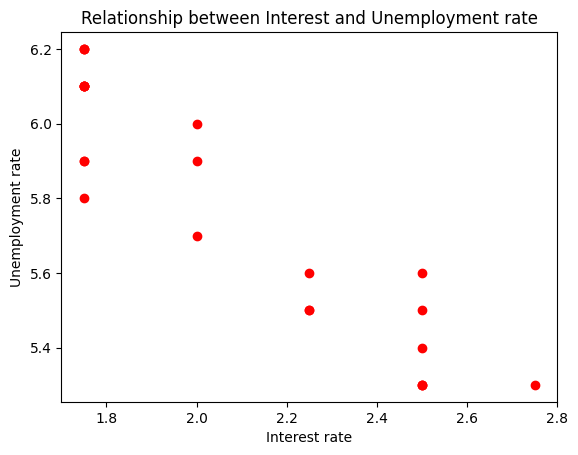

In [11]:
# Visualize the datapoints 
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel('Interest rate')
plt.ylabel('Unemployment rate')
plt.title('Relationship between Interest and Unemployment rate')

In [12]:
#Split Independent and Dependent feature
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [15]:
# Split train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

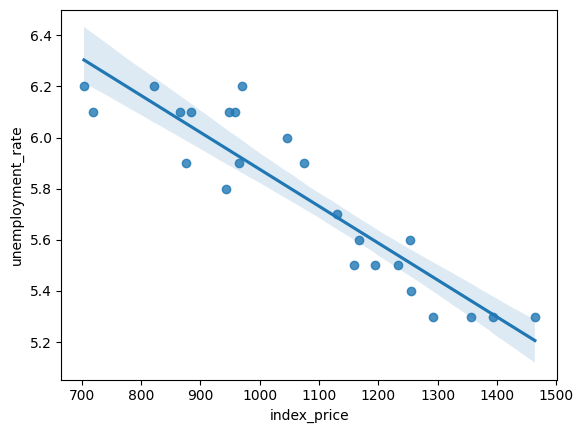

In [21]:
sns.regplot(x=df['index_price'],y=df['unemployment_rate'])

In [22]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [24]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error', cv=3)
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [ ]:
np.mean(validation_score) # Mean score of cross validation

np.float64(-5914.828180162388)

In [26]:
# Prediction 
y_pred = regression.predict(X_test)

In [28]:
## Performance metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [31]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)
print(r2_score(y_train,regression.predict(X_train)))

0.8278978091457145
0.9030782287244159


## Assumptions


In [32]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


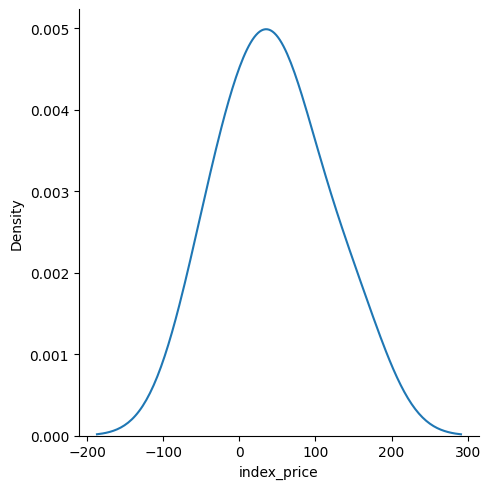

In [34]:
sns.displot(residuals,kind='kde')

<Axes: ylabel='index_price'>

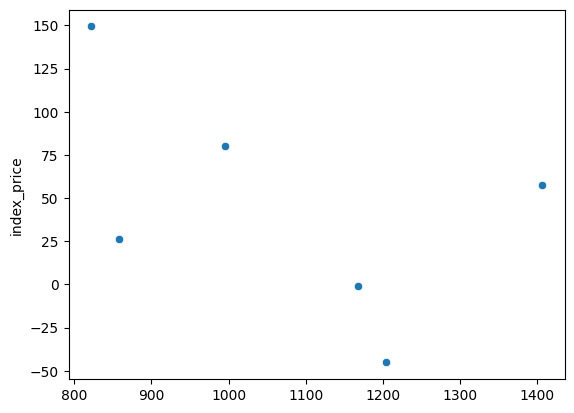

In [36]:
# Scatter plot with respect to prediction and residuals
sns.scatterplot(x=y_pred,y=residuals)

# OLS Linear Regression

In [38]:
import statsmodels.api as sm 
ols_model = sm.OLS(y_train, X_train).fit()
y_predict = ols_model.predict(X_test)
ols_model.summary()

c:\Users\battih\Desktop\Personal\Data Science\myvenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 21 Jun 2025   Prob (F-statistic):                       0.754
Time:                        17:42:33   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""